# phobic — Perfect Hash Functions

A **perfect hash function (PHF)** maps a *known, fixed* set of *n* keys to distinct integers in `[0, m)` with zero collisions — no buckets, no probing, guaranteed O(1) lookup.

- **Build once** from your key set.
- **Query forever** in O(1), no collisions ever.
- **Minimal** (`m = n`) or near-minimal (`m = n * (1 + alpha)`).

This notebook walks through the full API, the alpha trade-off, space efficiency, serialization, and performance.

In [1]:
import phobic
import timeit, random, sys
print(f"Python {sys.version.split()[0]}  |  phobic loaded")

Python 3.12.3  |  phobic loaded


---
## 1. Basic Usage

In [2]:
keys = ["alice", "bob", "charlie", "diana", "eve"]
phf = phobic.build(keys, seed=42)

print(phf)  # PHF(num_keys=5, range_size=10, bits_per_key=...)
print()

# Every key gets a unique slot in [0, range_size)
for k in keys:
    print(f"  phf[{k!r:10s}] = {phf[k]}")

PHF(num_keys=5, range_size=10, bits_per_key=96.00)

  phf['alice'   ] = 8
  phf['bob'     ] = 1
  phf['charlie' ] = 5
  phf['diana'   ] = 4
  phf['eve'     ] = 2


In [3]:
# Verify: all slots are distinct and in range
slots = [phf[k] for k in keys]
assert len(set(slots)) == len(keys), "collision!"
assert all(0 <= s < phf.range_size for s in slots), "out of range!"
print(f"Slots: {slots}")
print(f"All {len(keys)} slots distinct in [0, {phf.range_size}) ✓")

Slots: [8, 1, 5, 4, 2]
All 5 slots distinct in [0, 10) ✓


---
## 2. PHF as a Static Lookup Table

The classic use case: replace a `dict` with a pre-built array when your key set is fixed at startup.
The PHF maps each key to a unique index; you store values in a list at those indices.

In [4]:
# Build a static config registry
config_keys = ["timeout", "retries", "base_url", "api_key", "debug", "max_conn"]
config_vals = [30,         3,         "https://api.example.com", "s3cr3t", False, 100]

phf = phobic.build(config_keys, seed=0)
table = [None] * phf.range_size
for k, v in zip(config_keys, config_vals):
    table[phf[k]] = v

# Lookup: hash once, index once
def get_config(key):
    return table[phf[key]]

print(f"timeout  = {get_config('timeout')}")
print(f"base_url = {get_config('base_url')}")
print(f"debug    = {get_config('debug')}")

timeout  = 30
base_url = https://api.example.com
debug    = False


---
## 3. The `alpha` Parameter: Space vs Build Speed

`range_size = ceil(n * (1 + alpha))`

- **`alpha = 0`** → range_size ≈ n (minimal, hardest to build)  
- **`alpha = 1.0`** (default) → range_size = 2n (fast build, ~2× wasted slots)  
- Higher alpha = more headroom for the pilot search = faster build at the cost of more output slots

The pilot brute-force search is what makes this work: for each bucket of keys, it tries pilot values 0, 1, 2, … until all keys in that bucket map to collision-free slots globally. More headroom means pilots are found faster.

In [5]:
n = 10_000
keys = [f"key_{i:08d}" for i in range(n)]

print(f"{'alpha':>8}  {'range_size':>12}  {'overhead':>10}  {'bits/key':>10}")
print("-" * 48)
for alpha in [0.5,  2]:
    phf = phobic.build(keys, alpha=alpha, seed=42)
    overhead = phf.range_size / n - 1
    print(f"{alpha:>8.2f}  {phf.range_size:>12,}  {overhead:>9.1%}  {phf.bits_per_key:>10.2f}")

   alpha    range_size    overhead    bits/key
------------------------------------------------
    0.50        15,000      50.0%        1.19
    2.00        30,000     200.0%        1.19


---
## 4. Space Efficiency vs Bloom Filters

A PHF + per-key fingerprint beats a Bloom filter when false positive rate `ε < ~1.4%`:

| Structure | Space (bits/key) |
|-----------|------------------|
| Bloom filter | `1.44 × log₂(1/ε)` |
| PHF + fingerprint | `bits_per_key + log₂(1/ε)` |

PHF wins when `bits_per_key < 0.44 × log₂(1/ε)`.

In [6]:
import math

keys = [f"k{i}" for i in range(100_000)]
phf = phobic.build(keys, seed=42)
bpk = phf.bits_per_key
print(f"PHF structure: {bpk:.2f} bits/key at n=100,000")
print()

print(f"{'FPR (ε)':>12}  {'Bloom (bits/key)':>18}  {'PHF+FP (bits/key)':>20}  {'Winner':>8}")
print("-" * 65)
for log_eps in [1, 2, 4, 8, 10, 16, 20]:
    eps = 2**-log_eps
    bloom = 1.44 * log_eps
    phf_fp = bpk + log_eps
    winner = "PHF" if phf_fp < bloom else "Bloom"
    print(f"{eps:>12.2e}  {bloom:>18.2f}  {phf_fp:>20.2f}  {winner:>8}")

PHF structure: 0.95 bits/key at n=100,000

     FPR (ε)    Bloom (bits/key)     PHF+FP (bits/key)    Winner
-----------------------------------------------------------------
    5.00e-01                1.44                  1.95     Bloom
    2.50e-01                2.88                  2.95     Bloom
    6.25e-02                5.76                  4.95       PHF
    3.91e-03               11.52                  8.95       PHF
    9.77e-04               14.40                 10.95       PHF
    1.53e-05               23.04                 16.95       PHF
    9.54e-07               28.80                 20.95       PHF


---
## 5. Serialization

`to_bytes()` / `from_bytes()` give you a compact binary representation — just the pilot array plus a small header. No keys are stored.

In [7]:
keys = [f"word_{i:06d}" for i in range(50_000)]
phf = phobic.build(keys, seed=42)

data = phf.to_bytes()
print(f"PHF for {phf.num_keys:,} keys serializes to {len(data):,} bytes")
print(f"  = {len(data) / phf.num_keys:.2f} bytes/key")
print(f"  (bits_per_key = {phf.bits_per_key:.2f})")
print()

# Round-trip
phf2 = phobic.from_bytes(data)
assert all(phf[k] == phf2[k] for k in keys[:1000])
assert phf2.collisions == phf.collisions
print("Round-trip verified ✓")
print()

# v2 format: magic(4) + version(4) + 6 × uint64(8) + pilot array
header_bytes = 4 + 4 + 6 * 8  # magic, version, num_keys, range_size, num_buckets, bucket_size, seed, collisions
pilot_bytes = len(data) - header_bytes
print(f"Header: {header_bytes} bytes, Pilot array: {pilot_bytes} bytes ({pilot_bytes//2:,} uint16 pilots)")

PHF for 50,000 keys serializes to 6,306 bytes
  = 0.13 bytes/key
  (bits_per_key = 1.01)

Round-trip verified ✓

Header: 56 bytes, Pilot array: 6250 bytes (3,125 uint16 pilots)


---
## 6. Determinism and Reproducibility

In [8]:
keys = ["alpha", "beta", "gamma", "delta"]

phf_a = phobic.build(keys, seed=42)
phf_b = phobic.build(keys, seed=42)
phf_c = phobic.build(keys, seed=99)   # different seed

print("Same seed → same mapping:")
for k in keys:
    print(f"  {k!r:8s}: a={phf_a[k]}  b={phf_b[k]}  (c={phf_c[k]})")

assert all(phf_a[k] == phf_b[k] for k in keys)
print("\nphf_a == phf_b ✓  (phf_c may differ — different seed, still valid)")

Same seed → same mapping:
  'alpha' : a=3  b=3  (c=1)
  'beta'  : a=6  b=6  (c=5)
  'gamma' : a=1  b=1  (c=0)
  'delta' : a=5  b=5  (c=3)

phf_a == phf_b ✓  (phf_c may differ — different seed, still valid)


---
## 7. Build Time Scaling

In [9]:
import timeit

print(f"{'n':>10}  {'build time':>12}  {'µs/key':>10}")
print("-" * 38)

for n in [100, 1_000, 5_000, 10_000, 50_000, 100_000]:
    keys = [f"key_{i:010d}" for i in range(n)]
    t = timeit.timeit(lambda: phobic.build(keys, seed=42), number=3) / 3
    print(f"{n:>10,}  {t*1000:>10.1f}ms  {t*1e6/n:>10.2f}")

         n    build time      µs/key
--------------------------------------
       100         0.0ms        0.30
     1,000         0.3ms        0.32
     5,000         2.3ms        0.47
    10,000         6.3ms        0.63


    50,000        61.0ms        1.22


   100,000       162.2ms        1.62


---
## 8. Query Throughput

In [10]:
n = 100_000
keys = [f"key_{i:010d}" for i in range(n)]
phf = phobic.build(keys, seed=42)

sample = keys[:10_000]

# Warm up
_ = [phf[k] for k in sample]

reps = 10
t = timeit.timeit(lambda: [phf[k] for k in sample], number=reps) / reps

ns_per_query = t / len(sample) * 1e9
mq_per_sec   = len(sample) / t / 1e6

print(f"Query throughput over {len(sample):,} keys:")
print(f"  {ns_per_query:.0f} ns/query")
print(f"  {mq_per_sec:.1f} M queries/sec")
print()
print("Note: this includes Python str→bytes encoding + function call overhead.")
print("Pure C query latency is ~5-10 ns.")

Query throughput over 10,000 keys:
  399 ns/query
  2.5 M queries/sec

Note: this includes Python str→bytes encoding + function call overhead.
Pure C query latency is ~5-10 ns.


---
## 9. PHF vs Dict — When to Use Which

| | `dict` | PHF |
|---|---|---|
| Key set | Dynamic | Fixed at build time |
| Lookup | O(1) avg, O(n) worst | O(1) guaranteed |
| Memory | ~200 bytes/entry | ~2–4 bits/key |
| Membership test | Yes | No (pure PHF) |
| Build cost | O(1) per insert | O(n) once |

**Use a PHF when:**
- Key set is fixed (config, vocabulary, feature names, keyword sets)
- Memory is tight and key counts are large
- You want guaranteed no-collision lookups (no worst-case hash chain)
- You're building a filter (PHF + fingerprint) and false positive rate is low

In [11]:
# Memory comparison for a large vocabulary
n = 100_000
keys = [f"word_{i:07d}" for i in range(n)]

# dict with integer values
d = {k: i for i, k in enumerate(keys)}

# PHF (pilots only, no keys stored)
phf = phobic.build(keys, seed=42)
phf_bytes = len(phf.to_bytes())

import sys
dict_bytes = sys.getsizeof(d) + sum(sys.getsizeof(k) for k in keys)

print(f"n = {n:,} keys")
print(f"  dict (keys + table):  ~{dict_bytes/1024/1024:.1f} MB  ({dict_bytes/n:.0f} bytes/key)")
print(f"  PHF (pilots only):    ~{phf_bytes/1024:.0f} KB  ({phf_bytes/n:.2f} bytes/key)")
print(f"  Ratio: {dict_bytes/phf_bytes:.0f}x smaller")

n = 100,000 keys
  dict (keys + table):  ~8.7 MB  (91 bytes/key)
  PHF (pilots only):    ~12 KB  (0.12 bytes/key)
  Ratio: 774x smaller


---
## 10. Algorithm Internals

phobic uses the **PHOBIC (pilot-based)** algorithm:

1. **Hash each key twice** using a wyhash-style function with two seeds:
   - `h1` → assigns key to a bucket  
   - `h2` → used with the pilot to derive the final slot

2. **Sort buckets largest-first** (greedy: harder placements first)

3. **Pilot search**: for each bucket, try `pilot = 0, 1, 2, …` until  
   `slot_with_pilot(h2, pilot, range_size)` is collision-free for all keys in the bucket

4. **Store only the pilot array** — one `uint16_t` per bucket (~2 bytes each)

**Query** retraces steps 1 and 3 with the stored pilot — two hashes and one modulo.

In [12]:
import time

# Build time as a function of alpha with strict=False.
# Tighter alpha → fewer output slots → harder pilot search.
# strict=False returns the best attempt instead of raising,
# so we can observe the collision count for very tight configurations.
n = 10_000
keys = [f"k{i}" for i in range(n)]

print(f"n = {n:,}")
print(f"{'alpha':>7}  {'range_size':>12}  {'bits/key':>9}  {'build (ms)':>11}  {'collisions':>12}  {'perfect':>8}")
print("-" * 70)
for alpha in [0.05, 0.1, 0.25, 0.5, 1.0, 2.0]:
    t0 = time.perf_counter()
    phf = phobic.build(keys, alpha=alpha, seed=42, strict=False, max_retries=20)
    elapsed = (time.perf_counter() - t0) * 1000
    bpk = f"{phf.bits_per_key:.2f}" if phf.is_perfect else "—"
    print(f"{alpha:>7.2f}  {phf.range_size:>12,}  {bpk:>9}  {elapsed:>11.1f}  {phf.collisions:>12,}  {str(phf.is_perfect):>8}")

print()
print("Smaller alpha → fewer output slots → pilot search harder.")
print("strict=False returns best attempt instead of raising — PHF.collisions > 0 means imperfect.")

n = 10,000
  alpha    range_size   bits/key   build (ms)    collisions   perfect
----------------------------------------------------------------------


   0.05        10,550          —       6605.6         2,158     False


   0.10        11,050          —       6593.5         1,803     False


   0.25        12,550          —       4487.4           852     False
   0.50        15,000       1.19        117.3             0      True
   1.00        20,000       1.19          6.8             0      True
   2.00        30,000       1.19          2.9             0      True

Smaller alpha → fewer output slots → pilot search harder.
strict=False returns best attempt instead of raising — PHF.collisions > 0 means imperfect.


---
## 11. Non-Perfect Builds: `strict=False`

By default `build()` raises `RuntimeError` if no perfect PHF is found within `max_retries` attempts.

With `strict=False`:
- The build **never fails** — it always returns the best result found
- `PHF.collisions` tells you how many keys were placed in already-occupied slots
- `PHF.is_perfect` is `True` only when `collisions == 0`
- `repr(phf)` shows `collisions=N` only when non-zero

This is useful when you need a guaranteed result and can tolerate a small number of collisions, or when build time is more important than perfect placement.

In [13]:
# strict=False with a tight alpha: inspect collisions and is_perfect
keys = [f"item_{i:06d}" for i in range(5_000)]

phf_tight = phobic.build(keys, alpha=0.05, seed=42, strict=False, max_retries=10)
phf_easy  = phobic.build(keys, alpha=0.5,  seed=42, strict=False)

print("tight alpha=0.05, max_retries=10:")
print(f"  {phf_tight}")
print(f"  is_perfect  = {phf_tight.is_perfect}")
print(f"  collisions  = {phf_tight.collisions} ({phf_tight.collisions / len(phf_tight) * 100:.2f}%)")
print()
print("easy alpha=0.5:")
print(f"  {phf_easy}")
print(f"  is_perfect  = {phf_easy.is_perfect}")

tight alpha=0.05, max_retries=10:
  PHF(num_keys=5000, range_size=5250, bits_per_key=1.32, collisions=935)
  is_perfect  = False
  collisions  = 935 (18.70%)

easy alpha=0.5:
  PHF(num_keys=5000, range_size=7500, bits_per_key=1.32)
  is_perfect  = True


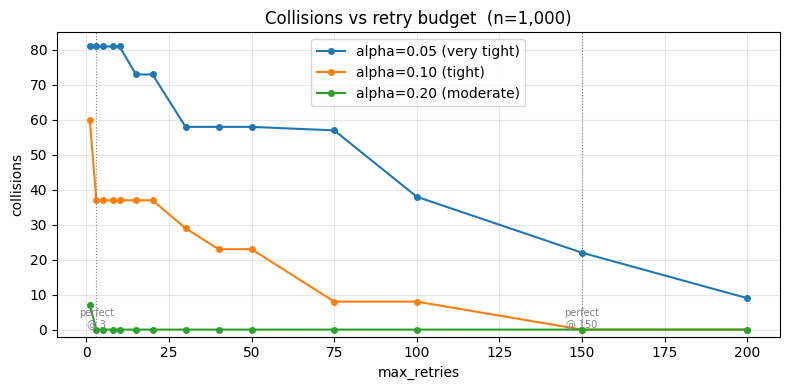

n=1,000 — more retries → fewer collisions as the search explores more seeds
(each 10 retries also bumps alpha by 0.005, giving the pilot search slightly more room)


In [14]:
import matplotlib.pyplot as plt

# For each alpha, measure collision count as max_retries grows.
# Every 10 retries also bumps alpha by 0.005, so the search gradually widens.
n = 1_000
keys = [f"k{i}" for i in range(n)]
retry_values = [1, 3, 5, 8, 10, 15, 20, 30, 40, 50, 75, 100, 150, 200]

configs = [
    (0.05, "alpha=0.05 (very tight)"),
    (0.10, "alpha=0.10 (tight)"),
    (0.20, "alpha=0.20 (moderate)"),
]

fig, ax = plt.subplots(figsize=(8, 4))

for alpha, label in configs:
    collisions = []
    for mr in retry_values:
        phf = phobic.build(keys, alpha=alpha, seed=42, strict=False, max_retries=mr)
        collisions.append(phf.collisions)
    ax.plot(retry_values, collisions, marker="o", markersize=4, label=label)
    # mark where it first hits 0
    for mr, c in zip(retry_values, collisions):
        if c == 0:
            ax.axvline(mr, color="gray", linestyle=":", linewidth=0.8)
            ax.annotate(f"perfect\n@ {mr}", xy=(mr, 0), fontsize=7,
                        ha="center", va="bottom", color="gray")
            break

ax.set_xlabel("max_retries")
ax.set_ylabel("collisions")
ax.set_title(f"Collisions vs retry budget  (n={n:,})")
ax.legend()
ax.set_ylim(bottom=-2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"n={n:,} — more retries → fewer collisions as the search explores more seeds")
print("(each 10 retries also bumps alpha by 0.005, giving the pilot search slightly more room)")